In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    classification_report
)

print("Scikit-learn imports successful!")

Scikit-learn imports successful!


In [5]:
import sys
print(sys.executable)

c:\python314\python.exe


In [3]:
import pandas as pd

df = pd.read_csv("customer-churn-training.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (12, 7)


,customer_id,tenure_months,support_tickets,monthly_spend_inr,last_login_days,plan_type,churned
0,C001,2,4,499,21,Basic,1
1,C002,18,1,1299,2,Pro,0
2,C003,6,3,799,14,Basic,1
3,C004,30,0,1499,1,Pro,0
4,C005,11,2,999,5,Standard,0


In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset shape:")
print(df.shape)

Columns:
['customer_id', 'tenure_months', 'support_tickets', 'monthly_spend_inr', 'last_login_days', 'plan_type', 'churned']

Data types:
customer_id            str
tenure_months        int64
support_tickets      int64
monthly_spend_inr    int64
last_login_days      int64
plan_type              str
churned              int64
dtype: object

Dataset shape:
(12, 7)


In [5]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
customer_id          0
tenure_months        0
support_tickets      0
monthly_spend_inr    0
last_login_days      0
plan_type            0
churned              0
dtype: int64

Duplicate rows:
0


In [6]:
print("Churn counts:")
print(df["churned"].value_counts())

print("\nChurn percentages:")
print((df["churned"].value_counts(normalize=True) * 100).round(2))

Churn counts:
churned
0    7
1    5
Name: count, dtype: int64

Churn percentages:
churned
0    58.33
1    41.67
Name: proportion, dtype: float64


NameError: name 'plt' is not defined

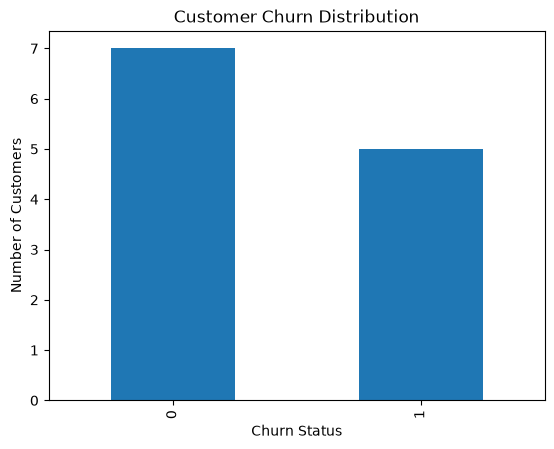

In [7]:
df["churned"].value_counts().sort_index().plot(
    kind="bar",
    title="Customer Churn Distribution",
    xlabel="Churn Status",
    ylabel="Number of Customers"
)

plt.xticks([0, 1], ["No Churn", "Churn"], rotation=0)
plt.tight_layout()
plt.show()

In [8]:
print("Plan type distribution:")
print(df["plan_type"].value_counts())

Plan type distribution:
plan_type
Basic       5
Standard    4
Pro         3
Name: count, dtype: int64


In [9]:
df.describe()

,tenure_months,support_tickets,monthly_spend_inr,last_login_days,churned
count,12.000000,12.000000,12.000000,12.000000,12.000000
mean,12.166667,2.250000,915.666667,10.000000,0.416667
std,9.242524,1.602555,332.574895,9.095453,0.514929
min,1.000000,0.000000,499.000000,1.000000,0.000000
25%,5.500000,1.000000,724.000000,2.750000,0.000000
50%,9.500000,2.000000,899.000000,7.000000,0.000000
75%,18.500000,3.250000,1074.000000,14.750000,1.000000
max,30.000000,5.000000,1499.000000,30.000000,1.000000


In [10]:
pd.crosstab(
    df["plan_type"],
    df["churned"],
    margins=True
)

churned,0,1,All
plan_type,,,
Basic,0,5,5
Pro,3,0,3
Standard,4,0,4
All,7,5,12


In [11]:
X = df.drop(columns=["churned", "customer_id"])
y = df["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 9
Testing samples: 3


In [13]:
import numpy as np
from sklearn.metrics import accuracy_score

majority_class = y_train.mode()[0]

baseline_predictions = np.full(
    len(y_test),
    majority_class
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print("Majority class:", majority_class)
print(f"Baseline accuracy: {baseline_accuracy:.3f}")

Majority class: 0
Baseline accuracy: 0.667


In [14]:
numeric_features = [
    "tenure_months",
    "support_tickets",
    "monthly_spend_inr",
    "last_login_days"
]

categorical_features = [
    "plan_type"
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['tenure_months', 'support_tickets', 'monthly_spend_inr', 'last_login_days']

Categorical features:
['plan_type']


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [16]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Logistic Regression model created successfully!")

Logistic Regression model created successfully!


In [17]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [18]:
y_pred = model.predict(X_test)

print("Actual values:")
print(y_test.to_numpy())

print("\nPredicted values:")
print(y_pred)

Actual values:
[1 0 0]

Predicted values:
[1 0 0]


In [19]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Model Evaluation")
print("-----------------")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-score : {f1:.3f}")

Model Evaluation
-----------------
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1-score : 1.000


Confusion Matrix:
[[2 0]
 [0 1]]


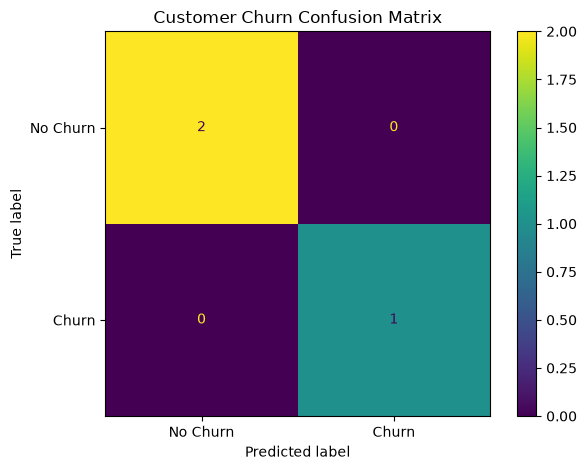

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Customer Churn Confusion Matrix")
plt.tight_layout()
plt.show()

In [22]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    No Churn       1.00      1.00      1.00         2
       Churn       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [23]:
y_probability = model.predict_proba(X_test)[:, 1]

if len(np.unique(y_test)) == 2:
    auc = roc_auc_score(y_test, y_probability)
    print(f"ROC-AUC: {auc:.3f}")
else:
    print("ROC-AUC cannot be calculated because the test set contains only one class.")

ROC-AUC: 1.000


In [24]:
results = X_test.copy()

results["actual_churn"] = y_test.values
results["predicted_churn"] = y_pred
results["churn_probability"] = y_probability.round(3)

results

,tenure_months,support_tickets,monthly_spend_inr,last_login_days,plan_type,actual_churn,predicted_churn,churn_probability
9,4,3,499,12,Basic,1,1,0.837
11,7,2,799,9,Standard,0,0,0.402
6,24,1,999,3,Standard,0,0,0.079


In [25]:
print("Performance Comparison")
print("----------------------")
print(f"Non-ML Baseline Accuracy     : {baseline_accuracy:.3f}")
print(f"Logistic Regression Accuracy : {accuracy:.3f}")

Performance Comparison
----------------------
Non-ML Baseline Accuracy     : 0.667
Logistic Regression Accuracy : 1.000


In [26]:
error_analysis = X_test.copy()

error_analysis["actual_churn"] = y_test.values
error_analysis["predicted_churn"] = y_pred

error_analysis["error_type"] = np.select(
    [
        (y_test.values == 0) & (y_pred == 1),
        (y_test.values == 1) & (y_pred == 0)
    ],
    [
        "False Positive",
        "False Negative"
    ],
    default="Correct"
)

error_analysis

,tenure_months,support_tickets,monthly_spend_inr,last_login_days,plan_type,actual_churn,predicted_churn,error_type
9,4,3,499,12,Basic,1,1,Correct
11,7,2,799,9,Standard,0,0,Correct
6,24,1,999,3,Standard,0,0,Correct


# Responsible ML Findings

## Baseline comparison

A majority-class non-ML baseline was established before evaluating the machine-learning model.

The baseline predicts the majority class observed in the training data for every test customer.

## Machine-learning baseline

A Logistic Regression classifier was used as the initial machine-learning baseline.

The model uses customer tenure, support tickets, monthly spending, last-login behavior, and plan type as candidate predictive features.

The customer identifier is excluded from model training because it is an identifier rather than a meaningful predictive feature.

## Evaluation

The model was evaluated using accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC where the test set contained both classes.

Precision and recall are considered alongside accuracy because false-positive and false-negative errors have different business consequences.

## Error analysis

False positives represent customers predicted to churn who did not actually churn.

False negatives represent customers predicted not to churn who actually churned.

Both error types should be monitored before any real-world deployment.

## Human review

The model should support human decision-making rather than automatically deciding what action should be taken against a customer.

Uncertain predictions should be referred for human review.

## Limitations

The supplied dataset contains only 12 customer records.

The test set is therefore very small, so the evaluation metrics may be unstable and should not be interpreted as reliable production performance.

A larger and representative dataset would be required before production deployment.

## Responsible use

The model should be treated as an experimental baseline for the internship task.

Before production use, the prediction horizon, data permissions, data collection process, leakage controls, business costs, fairness considerations, and monitoring requirements should be validated.